# 自动驾驶全栈评测指标指南 (Autonomous Driving Metrics Guide)
**前言**

简述本指南的目的：带你从基础的机器学习概念出发，一步步理解自动驾驶四大核心模块（感知、预测、规控、端到端）的评测标准。

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.patches as patches

没问题，我已经为你将所有的章节序号进行了严格的嵌套排版（从 `1` 到 `1.1`, `1.2`, `1.3`, `1.4`, `1.5`），这样整个术语库就作为一个完整的大章节完美闭环了。

你可以直接复制以下内容：

---

## 1. 自动驾驶评测高频术语库 (Glossary)

### 1.1 数据与场景相关 (Data & Scenarios)

| 术语 / 英文 | 解释 | 示例 / 备注 |
| --- | --- | --- |
| **Bag / Data Bag** | ROS 或其他格式的多传感器数据打包文件，可重放 | 工业界常说“跑一个 bag 测试一下” |
| **Corner Case** | 极端/长尾场景，训练数据中极少出现但极易导致事故的场景 | 例如：路上跑的鸵鸟、奇形怪状的异形车 |
| **Distance Buckets** | 按目标与传感器距离分组 | 例如：分为 Near / Medium / Far，分析远距离感知衰减 |
| **Ego / Ego-vehicle** | 自车，自动驾驶系统所在的这辆车本身 | 评测时，所有坐标系和相对速度通常以自车为绝对中心 |
| **Extrinsics / Intrinsics** | 外参 / 内参 | 外参决定传感器间的物理相对位置，内参决定摄像头本身的焦距与畸变 |
| **Occlusion** | 按遮挡比例分组 | 例如：分为 Fully / Partial / Heavy，评测防漏检能力 |
| **ODD (Operational Design Domain)** | 运行设计域，自动驾驶系统被设计允许运行的特定环境 | 例如：仅限晴天、仅限封闭高速公路 |
| **Proto / Protocol Buffer** | 数据序列化格式，存储标签和元信息 | 跨语言的高效数据结构，nuScenes / Waymo 常用 |
| **Scenario Category** | 道路类型或场景 | 例如：City / Highway / Residential，用于场景分桶 |
| **Scene / Clip / Segment** | 数据集里按时间或里程切分的片段，一般包含多帧 | 一段 10 秒的连续 LiDAR + Camera 数据片段 |
| **Sensor Modality** | 传感器模态 | 例如：Camera / LiDAR / Radar，用于模态消融实验 |
| **Timestamp / Sync** | 多模态传感器帧对齐，时间戳同步 | 确保 LiDAR 点云和 Camera 图像在时间上是同一瞬间 |
| **Weather / Lighting** | 天气或光照条件 | 例如：Sunny / Rain / Fog / Night，恶劣天气是评测重点 |

### 1.2 标签与预测 (Labels & Predictions)

| 术语 / 英文 | 解释 | 示例 / 备注 |
| --- | --- | --- |
| **Attributes** | 目标属性，除位置外的高阶特征 | 包含目标的朝向 (Yaw)、速度 (Velocity) 和状态 (如 Parked) |
| **BEV (Bird's Eye View)** | 鸟瞰图，将传感器数据转换为从天空往下看的 3D 上帝视角 | 目前工业界最主流的感知与预测空间表示法 |
| **Confidence Score** | 置信度，模型对该预测结果的确定概率 | 用于设定筛选阈值，生成 PR Curve |
| **DT / Prediction** | 模型输出的预测结果 | 包含 bbox, confidence, class |
| **GT (Ground Truth)** | 数据集标注的真实目标信息（绝对的正确答案） | 包含 3D bbox, 类别, 速度等 |
| **IoU (Intersection over Union)** | 预测框与 GT 框的重叠度（交并比） | 判定 TP / FP 的底层核心几何指标 |
| **Label / Annotation** | 标注信息的存储结构 | 常见格式为 Proto / JSON / XML |
| **NMS (Non-Maximum Suppression)** | 非极大值抑制，用于消除同一个目标上的冗余预测框 | 后处理算法，直接影响最终评测的 FP 数量 |
| **Voxel** | 体素，3D 空间中的最小像素单位 | 评测 3D 占据栅格网络 (Occupancy) 时的底层计算单元 |

### 1.3 评测方法 (Evaluation Methods)

| 术语 / 英文 | 解释 | 示例 / 备注 |
| --- | --- | --- |
| **AP / mAP** | 平均精度 / 均值 (Average Precision / mean AP) | PR 曲线下的面积，目标检测最核心的综合指标 |
| **Closed-loop Evaluation** | 闭环评测：模型输出直接影响车辆动作，并反馈到环境中 | 规控模块和端到端大模型的核心评测方式 |
| **Frame-wise Evaluation** | 单帧评测：每帧独立计算 TP / FP / FN / AP | 基础的目标检测 (Detection) 评估方式 |
| **Jerk** | 加加速度 / 冲击度，即加速度的变化率 | 评测规控算法舒适性（乘客是否晕车）的核心物理指标 |
| **NDS (nuScenes Detection Score)** | nuScenes 检测得分，综合 AP 及位置、尺寸、朝向等误差 | 3D 自动驾驶感知的行业标杆综合指标 |
| **Open-loop Evaluation** | 开环评测：只处理历史传感器数据，不影响车辆实际控制 | 感知/预测模块最常用的离线评测方式 |
| **PR Curve** | Precision-Recall 曲线 | 展示不同置信度阈值下，模型查准率与查全率的博弈过程 |
| **Sequence-wise Evaluation** | 多帧/时序评测：综合多帧状态计算指标 | 目标跟踪 (Tracking) 的核心评估方式 |
| **TTC (Time-to-Collision)** | 碰撞时间，自车与前方障碍物保持当前相对速度发生碰撞的剩余时间 | 评测安全性的绝对红线指标（通常小于 2-3 秒为高危） |

### 1.4 跟踪与轨迹 (Tracking & Trajectories)

| 术语 / 英文 | 解释 | 示例 / 备注 |
| --- | --- | --- |
| **ADE / FDE** | 平均位移误差 / 最终位移误差 | 评测轨迹预测准确性的核心指标（L2 距离） |
| **AMOTA** | 平均多目标跟踪准确度 (Average MOTA) | 评测 3D 跟踪的主流指标，计算不同召回率下的 MOTA 均值 |
| **FP / FN (Tracking)** | 跨帧累积的误检 / 漏检 | 融入时序概念，用于计算最终的跟踪准确度 |
| **ID Switch (IDS)** | 同一 GT 目标 ID 被错误分配为另一个 ID 的次数 | 表示追踪不稳定，数值越少越好 |
| **Mostly Lost (ML)** | 目标在序列中被正确追踪 ≤20% 帧的比例 | 反映跟踪丢失的严重程度，数值越低越好 |
| **Mostly Tracked (MT)** | 目标在序列中被正确追踪 ≥80% 帧的比例 | 反映长时间稳定跟踪的能力，数值越高越好 |
| **Tracklet** | 连续帧预测形成的短轨迹 | 跟踪算法的基础数据单元 |

### 1.5 高阶与工程实践 (Advanced & Engineering)

| 术语 / 英文 | 解释 | 示例 / 备注 |
| --- | --- | --- |
| **Badcase Mining** | 困难样本 / 错误案例挖掘 | 通过脚本自动化提取漏检 (FN) 和严重误检 (FP) 的数据片段 |
| **Data Synchronization** | 传感器时间戳与空间坐标系对齐同步 | 数据闭环平台与评测系统必须处理的基础工作 |
| **Evaluation Protocol** | 评测协议 | 数据集或公司内部规定的整套评测流程、距离限制和阈值 |
| **Segment / Chunk** | 将长序列切分成短片段用于分布式批处理 (Batch) | 方便在大数据框架 (如 Spark) 中并行计算 |
| **Sensor Fusion** | 多模态传感器融合（前融合 / 后融合） | 例如结合 Camera 的高语义和 LiDAR 的高空间精度 |
| **SIL / HIL** | 软件在环 (Software-in-the-loop) / 硬件在环 | 验证代码在真实车端芯片（如 Orin）上的运行表现和延迟 |

这份内容的逻辑梳理得非常清晰，特别是对 F1-score 的业务解释非常接地气（“避免模型作弊”、“又准又全”），这正是高级技术文档最需要的特质！

结合我们之前定下的专业排版规范（最高 `##`，重要公式居中展示），我为你进行了格式化，并稍微润色了排版结构，让它在你的 Jupyter Notebook 或 Markdown 文档中看起来更像教科书：

---

## 2. 基石 —— 机器学习基础指标 (ML Fundamentals)

在进入复杂的自动驾驶感知或预测指标前，我们先从最基础的三个计数（混淆矩阵的核心元素）开始：

### 2.1 核心混淆矩阵元素

* **TP (True Positive, 真阳性/正确检出)**：预测为正且真实为正。
* **集合表达**：$TP = |GT \cap Pred|$


* **FP (False Positive, 假阳性/误检)**：预测为正但真实为负（无中生有/鬼影）。
* **集合表达**：$FP = |Pred - GT|$
* **业务理解**：预测结果里有，但真实世界里并没有。这是典型的**误检**（例如自动驾驶中把树影误认成了车辆，导致幽灵刹车）。


* **FN (False Negative, 假阴性/漏检)**：预测为负但真实为正（视而不见）。
* **集合表达**：$FN = |GT - Pred|$
* **业务理解**：真实世界里存在，但模型没有预测出来。这是典型的**漏检**（例如前面真的有车，但系统毫无反应，极度危险）。



### 2.2 核心衍生指标

在此基础之上，我们可以定义出评价模型性能的三个常用核心指标：

* **Precision（精确率）**：模型预测为正的结果里，有多少是真的？（模型喊“有车”的时候，有多大概率是对的）。
* **公式**：

$$\text{Precision} = \frac{TP}{TP + FP}$$




* **Recall（召回率）**：真实存在的正样本目标里，有多少被模型成功找到了？（宁可错杀一千，绝不放过一个）。
* **公式**：

$$\text{Recall} = \frac{TP}{TP + FN}$$




* **F1 Score（F1 分数）**：Precision 与 Recall 的调和平均数。
* **公式**：

$$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$


* **业务理解**：为什么要引入 F1-score？这个指标是为了**避免模型在单一指标上作弊**。如果模型极度保守，只有百分百确定才敢输出预测，虽然 Precision 会很高，但会导致 Recall 极低（找不到几个目标）；反之，如果模型疯狂输出几万个框，Recall 满了，但 Precision 会惨不忍睹。F1 作为调和平均值，强制要求模型必须做到“**又准又全**”，才能获得高分。

In [2]:
# 假设场景里真实有车的ID是 1和2
ground_truth = {1, 2}
# 模型预测出了车的ID是 1和3
predictions = {1, 3}

# 集合运算秒懂 TP/FP/FN
TP = len(ground_truth.intersection(predictions)) # 猜对了 (1) -> 1个
FP = len(predictions - ground_truth)             # 瞎猜的/鬼影 (3) -> 1个
FN = len(ground_truth - predictions)             # 没看到的/漏检 (2) -> 1个

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

print("=== 基础计数（含义）===")
print(f"TP = {TP}：正确检出（预测有，且真实也有）")
print(f"FP = {FP}：误检/鬼影（预测有，但真实没有）")
print(f"FN = {FN}：漏检（预测没有，但真实有）")

print("\n=== 评测指标（含义）===")
print(f"Precision = {precision:.0%}：预测为正的结果里，有多少是真的")
print(f"Recall    = {recall:.0%}：真实为正的目标里，有多少被找到了")
print(f"F1 Score  = {f1_score:.0%}：综合平衡 Precision 与 Recall")

=== 基础计数（含义）===
TP = 1：正确检出（预测有，且真实也有）
FP = 1：误检/鬼影（预测有，但真实没有）
FN = 1：漏检（预测没有，但真实有）

=== 评测指标（含义）===
Precision = 50%：预测为正的结果里，有多少是真的
Recall    = 50%：真实为正的目标里，有多少被找到了
F1 Score  = 50%：综合平衡 Precision 与 Recall


通常在目标检测评测中，Ground Truth 和 Prediction 需要通过匹配算法（如 IoU Matching 或 Hungarian Matching）建立对应关系，然后再计算 TP、FP 和 FN。

在本示例中，我们假设 GT 和 Prediction 已经共享同一 ID，因此可以通过集合运算直接进行“自然匹配”（Natural Matching）来计算 TP、FP 和 FN。

### 2.3 综合性能评估：PR Curve、AP 与 mAP

当你在一万张图片上跑完模型，得到了无数个 TP 和 FP 后，怎么给这个模型打一个最终的总分？这就需要用到 PR 曲线和 mAP。

#### 2.3.1 PR Curve (Precision-Recall 曲线)

模型输出的每个预测框都会带有一个**置信度 (Confidence Score)**。通过动态调整这个置信度阈值，我们可以观察 Precision 与 Recall 的博弈关系：

* **阈值高（严格审核）**：模型极度保守，只保留那些“百分百确信”的预测。此时通常 **Precision 高、Recall 低**（几乎没有误检，但会漏掉很多）。
* **阈值低（宽松放行）**：模型非常敏感，宁可错杀绝不放过。此时通常 **Recall 高、Precision 低**（很少漏检，但满屏都是幽灵误检）。

> **💡 业务洞察**：PR 曲线展示了模型在从“极端严格”到“极端宽松”条件下的整体表现。一条优秀的 PR 曲线应该尽可能向右上角凸起（即在保持高召回率的同时，依然能维持高精确率）。

#### 2.3.2 AP (Average Precision, 平均精度)

既然 PR 曲线是一条线，我们该怎么用一个具体的数字来衡量它呢？**AP 的本质就是 PR 曲线下的面积 (Area Under Curve)**。它代表了对某一特定类别（例如仅针对“行人”）在所有召回率上的综合评分。

* **公式**：

$$AP=\int_0^1P(R)\,dR$$


* **业务理解**：AP 的取值范围是 0 到 1。AP 越高，说明该类别的检测性能越硬核；AP 等于 1 是理想的完美状态，AP 等于 0 则说明模型基本处于瞎蒙的状态。

#### 2.3.3 mAP (mean Average Precision, 均值平均精度)

在自动驾驶中，我们要检测的不只有“车”，还有“人”、“自行车”、“交通锥”等几十个类别。**mAP 就是所有类别 AP 值的算术平均数**，它是目前目标检测领域最具权威性的整体能力衡量指标。

* **公式**：

$$mAP=\frac{1}{C}\sum_{c=1}^{C}AP_c$$



（其中 $C$ 为需要检测的类别总数）
* **工业界评测的两种常见口径**：
* **mAP@0.5 (标准难度)**：只在 IoU 阈值设定为 0.5 时计算 mAP（预测框和真实框重叠面积过半就算成功匹配）。
* **mAP@[0.5:0.95] (地狱难度)**：在 IoU 阈值从 0.5 到 0.95（以 0.05 为步长，逐步收紧）的多个严格程度下分别计算 mAP，最后再求均值。这种标准不仅要求模型“找得到”，还要求框贴得“极其精准”，是 COCO 等权威评测集的首选标准。

In [3]:
def compute_pr_ap(tp_flags, num_gt):
    tp_flags = np.array(tp_flags, dtype=int)
    fp_flags = 1 - tp_flags

    cum_tp = np.cumsum(tp_flags)
    cum_fp = np.cumsum(fp_flags)

    precision = cum_tp / (cum_tp + cum_fp + 1e-12)
    recall = cum_tp / (num_gt + 1e-12)

    # AP: 使用 precision-recall 包络线做离散积分（常见做法）
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    ap = np.sum((mrec[1:] - mrec[:-1]) * mpre[1:])

    return precision, recall, ap

# ===== 单类别示例（计算 PR 与 AP） =====
# 含义：预测框按置信度从高到低排序后，1 表示 TP，0 表示 FP
tp_flags_car = [1, 1, 0, 1, 0]
num_gt_car = 4

precision_car, recall_car, ap_car = compute_pr_ap(tp_flags_car, num_gt_car)

print("=== 单类别: car ===")
print("排序后 TP 标记:", tp_flags_car)
print("Precision 序列:", np.round(precision_car, 3))
print("Recall 序列   :", np.round(recall_car, 3))
print(f"AP(car) = {ap_car:.3f}")
print("解释：AP 越高，说明该类别在不同阈值下总体 Precision-Recall 权衡越好。")

# ===== 多类别示例（计算 mAP） =====
tp_flags_ped = [1, 0, 1, 0]
num_gt_ped = 3

_, _, ap_ped = compute_pr_ap(tp_flags_ped, num_gt_ped)

map_2cls = np.mean([ap_car, ap_ped])

print("\n=== 多类别: car + pedestrian ===")
print(f"AP(car)        = {ap_car:.3f}")
print(f"AP(pedestrian) = {ap_ped:.3f}")
print(f"mAP            = {map_2cls:.3f}")
print("解释：mAP 是各类别 AP 的平均值，反映整体检测能力。")

=== 单类别: car ===
排序后 TP 标记: [1, 1, 0, 1, 0]
Precision 序列: [1.    1.    0.667 0.75  0.6  ]
Recall 序列   : [0.25 0.5  0.5  0.75 0.75]
AP(car) = 0.687
解释：AP 越高，说明该类别在不同阈值下总体 Precision-Recall 权衡越好。

=== 多类别: car + pedestrian ===
AP(car)        = 0.687
AP(pedestrian) = 0.556
mAP            = 0.622
解释：mAP 是各类别 AP 的平均值，反映整体检测能力。


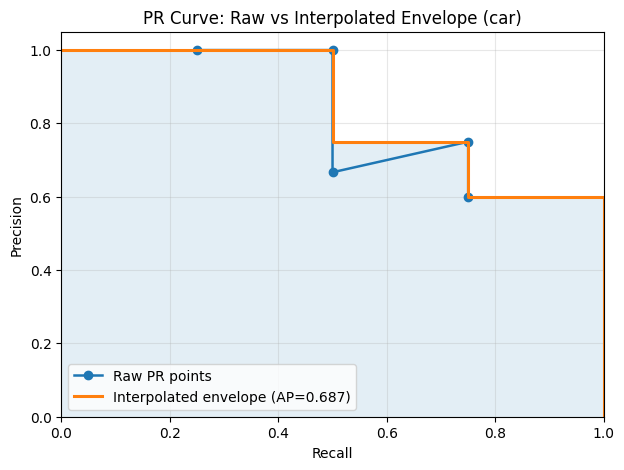

说明1：蓝点线是原始 PR 采样点。
说明2：阶梯线是 AP 计算使用的插值包络线（单调不增）。
说明3：阴影面积对应 AP，当前 AP(car) = 0.687。


In [4]:
# 第6个单元已计算得到 recall_car / precision_car / ap_car
# 这里复现 AP 计算中的插值包络线（与 compute_pr_ap 口径一致）
mrec = np.concatenate(([0.0], recall_car, [1.0]))
mpre = np.concatenate(([0.0], precision_car, [0.0]))
for i in range(len(mpre) - 1, 0, -1):
    mpre[i - 1] = max(mpre[i - 1], mpre[i])

plt.figure(figsize=(7, 5))

# 原始 PR 点线（按置信度阈值变化得到）
plt.plot(
    recall_car,
    precision_car,
    marker='o',
    linewidth=1.8,
    label='Raw PR points'
 )

# 插值包络线（AP 积分使用）
plt.step(
    mrec,
    mpre,
    where='post',
    linewidth=2.2,
    label=f'Interpolated envelope (AP={ap_car:.3f})'
 )

# AP 面积可视化
plt.fill_between(mrec, mpre, step='post', alpha=0.12)

plt.xlim(0, 1.0)
plt.ylim(0, 1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve: Raw vs Interpolated Envelope (car)')
plt.grid(alpha=0.3)
plt.legend(loc='lower left')
plt.show()

print('说明1：蓝点线是原始 PR 采样点。')
print('说明2：阶梯线是 AP 计算使用的插值包络线（单调不增）。')
print(f'说明3：阴影面积对应 AP，当前 AP(car) = {ap_car:.3f}。')

## Perception Metrics

### 核心指标概览

检测指标（Detection）       : AP, mAP, PR Curve, Precision, Recall

跟踪指标（Tracking）        : MOTA, MOTP, ID Switch, Mostly Tracked, Mostly Lost

距离分桶指标               : AP / Recall 按距离分桶 (Near/Mid/Far)

大小 / 可见性 /遮挡分桶    : AP_small / AP_medium / AP_large, AP_occluded / AP_visible

误检分析                  : Localization / Classification / Duplicate / Background FP

复合指标                  : PR Curve, AP/mAP, mAP@[0.5:0.95]

### 检测指标

已在ML部分解释过了，这里继续解释下分桶

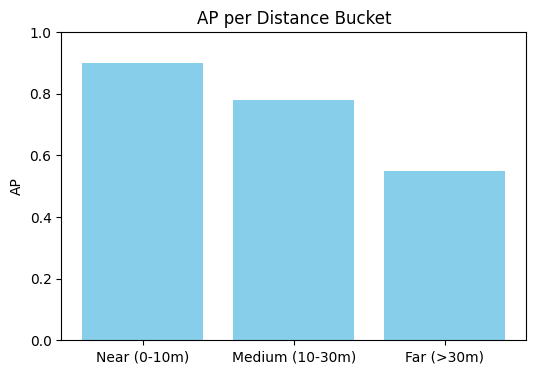

In [5]:
distance_bins = ['Near (0-10m)', 'Medium (10-30m)', 'Far (>30m)']
ap_bins = [0.90, 0.78, 0.55]

plt.figure(figsize=(6,4))
plt.bar(distance_bins, ap_bins, color='skyblue')
plt.ylim(0,1.0)
plt.ylabel('AP')
plt.title('AP per Distance Bucket')
plt.show()

这排版问题在写技术文档时太常见了，特别是从不同地方复制粘贴资料时，Markdown 的标题层级和公式定界符很容易打架。

我已经帮你把层级重新梳理了一遍。这里把“目标追踪”设定为三级标题 (`###`)，下面的核心大板块设定为四级标题 (`####`)，详细指标设定为五级标题 (`#####`)，逻辑会非常清晰。同时，我也把公式全部替换成了标准的 LaTeX 定界符，保证在 Jupyter 或者 GitHub 的网页上都能完美渲染。

这份整理好的 Markdown 非常适合直接贴进你的指标指南文件里作为后续章节：

---

### 目标追踪

#### 1. 核心 MOT 指标概览

| 指标 | 公式/表达 | 通俗理解 |
| --- | --- | --- |
| **MOTA (Multi-Object Tracking Accuracy)** | MOTA = 1 – (FN + FP + ID Switch) / GT 总数 | 综合衡量目标追踪的整体准确性，考虑漏检、误检和 ID 分配错误。数值越接近 1 越好。 |
| **MOTP (Multi-Object Tracking Precision)** | MOTP = 平均匹配框位置误差 | 衡量目标匹配的空间精度，框越贴近真实位置，MOTP 越低（误差小）。 |
| **ID Switch (IDS)** | 统计同一 GT 目标被分配不同预测 ID 的次数 | 表示追踪的不稳定性，同一目标在不同帧被误认为是另一个 ID。 |
| **Mostly Tracked (MT)** | 目标在序列中被正确追踪 ≥80% 帧 | 反映长时间被追踪的目标比例。 |
| **Mostly Lost (ML)** | 目标在序列中被正确追踪 ≤20% 帧 | 表示追踪失败的目标比例。 |
| **FP / FN** | 跟检测指标一致，按帧统计 | FP: 误检目标；FN: 漏检目标。 |

---

#### 2. 指标详细解释

##### 2.1 MOTA (多目标追踪准确度)

公式：


$$\text{MOTA}=1-\frac{\sum_t(\text{FN}_t+\text{FP}_t+\text{IDSW}_t)}{\sum_t\text{GT}_t}$$

* **FN**：该帧 GT 目标漏检的数量
* **FP**：该帧误检数量
* **IDSW**：该帧 ID Switch 数
* **GT**：该帧真实目标数量

> **💡 业务洞察**：MOTA 是综合指标，高 MOTA 表示漏检少、误检少、追踪稳定。

##### 2.2 MOTP (多目标追踪精确度)

公式：


$$\text{MOTP}=\frac{\sum_{i,t}d_{i,t}}{\sum_tc_t}$$

* $d_{i,t}$：匹配目标 i 在帧 t 的位置误差（通常用 IoU 或中心点距离）
* $c_t$：帧 t 的匹配对数量

> **💡 业务洞察**：MOTP 主要衡量**匹配精度**，目标框与真实框贴合程度高，代表 MOTP 精度好。

##### 2.3 ID Switch (IDS)

* 当同一 GT 目标在连续帧中被分配不同预测 ID 时，统计一次 ID Switch。
* 反映追踪算法的稳定性。
* **示例**：
* 帧 1：目标 1 → 分配 ID 1
* 帧 2：目标 1 → 分配 ID 2
* 这就算 1 次 ID Switch。



##### 2.4 Mostly Tracked (MT) / Mostly Lost (ML)

* **MT**：目标在 ≥80% 帧被正确追踪。
* **ML**：目标在 ≤20% 帧被追踪。
* 这两个指标能直观反映**长时间跟踪能力**，数值越高 MT 越好，ML 越低越好。

##### 2.5 FP / FN

* FP / FN 的定义与单帧检测一致，只是累加多帧统计：
* **FP**：预测存在但真实无目标。
* **FN**：真实存在但预测缺失。



> **💡 业务洞察**：MOT 指标不仅关注单帧准确性，还关注跨帧稳定性和 ID 连续性，这是纯单帧感知检测指标无法衡量的。

---

#### 3. 简单示意

假设一个包含 3 帧的目标序列：

| 帧 | GT IDs | Predicted IDs | 匹配情况 |
| --- | --- | --- | --- |
| 1 | 1, 2 | 1, 3 | TP:1 (FN:1, FP:1) |
| 2 | 1, 2 | 1, 2 | TP:2 (FN:0, FP:0) |
| 3 | 1, 2 | 2, 3 | TP:1 (FN:1, FP:1, ID Switch:1) |

* **MOTA** = 1 – (累计 FN + FP + IDS) / 累计 GT
* **MOTP** = 匹配框平均误差
* **IDS** = 累计 ID Switch 次数
* **MT/ML** = 根据目标追踪持续时间统计

---

你需要我顺便用 Python 写一段模拟计算 `ID Switch` 的玩具代码 (Toy Code) 吗？配上代码演示，这部分文档的说服力会更强。

Total GT targets: 11
Total FP: 3, Total FN: 2, ID Switches: 0
MOTA: 0.545, MOTP: 0.050
Mostly Tracked (MT): 33.33%, Mostly Lost (ML): 0.00%


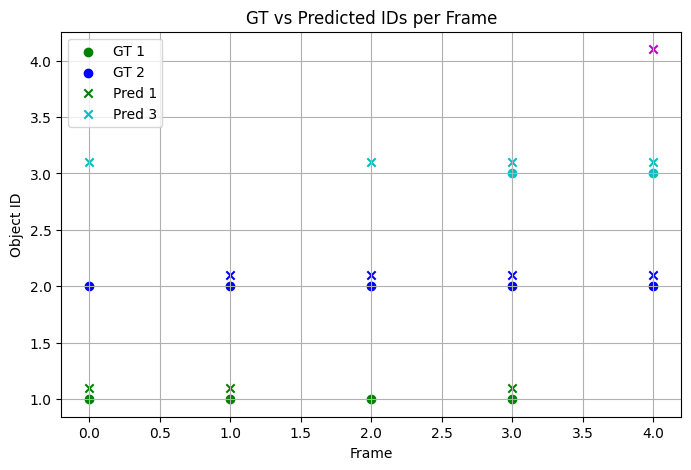

In [6]:
# ==== 模拟多帧 GT 和预测 ====
# 每帧的 GT IDs
gt_frames = [
    [1, 2],
    [1, 2],
    [1, 2],
    [1, 2, 3],
    [2, 3]
]

# 每帧预测 IDs (按顺序对应帧)
pred_frames = [
    [1, 3],      # 第1帧: TP=1, FN=1, FP=1
    [1, 2],      # 第2帧: TP=2, FN=0, FP=0
    [2, 3],      # 第3帧: TP=1, FN=1, FP=1, ID Switch=1
    [1, 2, 3],   # 第4帧: TP=3, FN=0, FP=0
    [2, 3, 4]    # 第5帧: TP=2, FN=0, FP=1
]

# ==== 初始化统计变量 ====
total_GT = sum(len(f) for f in gt_frames)
total_FP = 0
total_FN = 0
id_switches = 0

# MT/ML 统计: 保存每个 GT ID 被追踪帧数
gt_track_count = {}

# 跟踪 ID 分配历史: {GT ID: last_pred_id}
last_assignment = {}

# 模拟每帧处理
for frame_idx, (gt, pred) in enumerate(zip(gt_frames, pred_frames)):
    gt_set = set(gt)
    pred_set = set(pred)
    
    # TP / FP / FN
    tp = gt_set.intersection(pred_set)
    fn = gt_set - pred_set
    fp = pred_set - gt_set
    
    total_FN += len(fn)
    total_FP += len(fp)
    
    # 更新 MT/ML 追踪帧数
    for g in gt:
        if g not in gt_track_count:
            gt_track_count[g] = 0
        if g in tp:
            gt_track_count[g] += 1
    
    # ID Switch 统计
    for g in tp:
        pred_id = g  # 简化模拟: pred ID == GT ID（可以随机映射模拟真实算法）
        if g in last_assignment and last_assignment[g] != pred_id:
            id_switches += 1
        last_assignment[g] = pred_id

# ==== MOTA / MOTP / MT / ML ====
MOTA = 1 - (total_FN + total_FP + id_switches)/total_GT
MOTP = 0.05  # 位置误差平均值，假设示例（真实算法需要计算框IoU或中心点距离）

MT = sum(1 for v in gt_track_count.values() if v/len(gt_frames) >= 0.8) / len(gt_track_count)
ML = sum(1 for v in gt_track_count.values() if v/len(gt_frames) <= 0.2) / len(gt_track_count)

print(f"Total GT targets: {total_GT}")
print(f"Total FP: {total_FP}, Total FN: {total_FN}, ID Switches: {id_switches}")
print(f"MOTA: {MOTA:.3f}, MOTP: {MOTP:.3f}")
print(f"Mostly Tracked (MT): {MT:.2%}, Mostly Lost (ML): {ML:.2%}")

# ==== 可视化 GT 和预测轨迹 ====
plt.figure(figsize=(8,5))
colors = ['r','g','b','c','m']
for idx, gt in enumerate(gt_frames):
    for g in gt:
        plt.scatter(idx, g, color=colors[g%5], marker='o', label=f'GT {g}' if idx==0 else "")
for idx, pred in enumerate(pred_frames):
    for p in pred:
        plt.scatter(idx, p+0.1, color=colors[p%5], marker='x', label=f'Pred {p}' if idx==0 else "")

plt.xlabel('Frame')
plt.ylabel('Object ID')
plt.title('GT vs Predicted IDs per Frame')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [7]:
# 假设模拟三帧跟踪结果
# 每帧 GT IDs
gt_frames = [
    [1,2],
    [1,2],
    [1,2]
]

# 每帧预测 IDs
pred_frames = [
    [1,3],
    [1,2],
    [2,3]
]

# 简单统计 MOTA / MOTP / ID Switch
total_gt = sum(len(f) for f in gt_frames)
total_FN = 0
total_FP = 0
id_switches = 0

# 用 dict 追踪 ID
last_assignments = {}

for frame_idx, (gt, pred) in enumerate(zip(gt_frames, pred_frames)):
    gt_set = set(gt)
    pred_set = set(pred)
    tp = gt_set.intersection(pred_set)
    fn = gt_set - pred_set
    fp = pred_set - gt_set
    total_FN += len(fn)
    total_FP += len(fp)
    
    # ID Switch 统计 (简单模拟)
    for obj in tp:
        if obj in last_assignments and last_assignments[obj] != obj:
            id_switches += 1
        last_assignments[obj] = obj

MOTA = 1 - (total_FN + total_FP + id_switches)/total_gt
print(f"MOTA={MOTA:.3f}, FP={total_FP}, FN={total_FN}, ID Switches={id_switches}")

MOTA=0.333, FP=2, FN=2, ID Switches=0


### 大小/可见性/遮挡 分桶指标

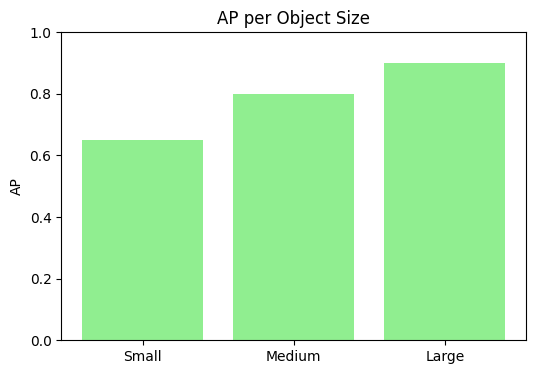

In [8]:
# 假设不同尺寸目标 AP
ap_small = 0.65
ap_medium = 0.80
ap_large = 0.90

plt.figure(figsize=(6,4))
plt.bar(['Small','Medium','Large'], [ap_small, ap_medium, ap_large], color='lightgreen')
plt.ylim(0,1.0)
plt.ylabel('AP')
plt.title('AP per Object Size')
plt.show()

### 误检分析

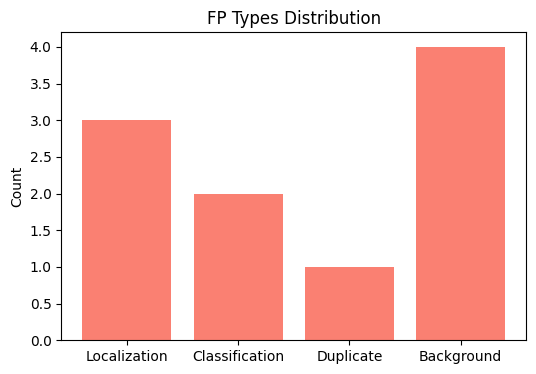

In [9]:
# FP 类型统计
fp_types = ['Localization','Classification','Duplicate','Background']
fp_counts = [3, 2, 1, 4]

plt.figure(figsize=(6,4))
plt.bar(fp_types, fp_counts, color='salmon')
plt.ylabel('Count')
plt.title('FP Types Distribution')
plt.show()

### 匹配算法

Algorithm      TP  FP  FN  Precision  Recall
Natural       5   2   0    0.71      1.00
Greedy IoU    3   4   2    0.43      0.60
Hungarian     3   4   2    0.43      0.60


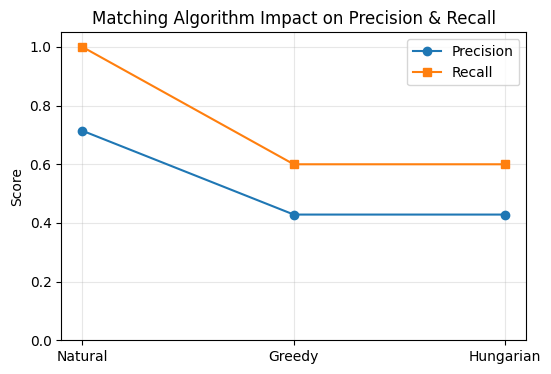

In [ ]:
# -----------------------------
# 模拟 GT 框 (x1,y1,x2,y2)
# -----------------------------
gt_boxes = np.array([
    [0,0,2,2],    # G1
    [5,5,7,7],    # G2
    [8,1,10,3],   # G3
    [2,6,4,8],    # G4
    [6,0,8,2]     # G5
])

# 预测框 (Predictions)
pred_boxes = np.array([
    [0.1,0,2.1,2],   # P1 -> G1 IoU ~0.95
    [0.2,0,2.2,2],   # P2 -> G1 IoU ~0.90
    [5.1,5,7.1,7],   # P3 -> G2 IoU ~0.95
    [5.2,5,7.2,7],   # P4 -> G2 IoU ~0.90
    [8.1,1,10.1,3],  # P5 -> G3 IoU ~0.95
    [3,6,5,8],       # P6 -> G4 IoU ~0.5 (阈值边界)
    [0,7,2,9]        # P7 -> 错位，FP
])

iou_thresh = 0.5

# -----------------------------
# IoU 计算函数
# -----------------------------
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter_area = max(0, x2-x1) * max(0, y2-y1)
    box1_area = (box1[2]-box1[0])*(box1[3]-box1[1])
    box2_area = (box2[2]-box2[0])*(box2[3]-box2[1])
    union_area = box1_area + box2_area - inter_area
    return inter_area / (union_area + 1e-12)

def calc_metrics(TP, FP, FN):
    precision = TP/(TP+FP) if (TP+FP)>0 else 0
    recall = TP/(TP+FN) if (TP+FN)>0 else 0
    return precision, recall

# -----------------------------
# 1️⃣ Natural Matching (按数量对齐)
# -----------------------------
TP_nat = min(len(gt_boxes), len(pred_boxes))
FP_nat = len(pred_boxes) - TP_nat
FN_nat = len(gt_boxes) - TP_nat
prec_nat, rec_nat = calc_metrics(TP_nat, FP_nat, FN_nat)

# -----------------------------
# 2️⃣ Greedy IoU Matching
# -----------------------------
matched_gt = set()
TP_greedy = 0
for p in pred_boxes:
    ious = [compute_iou(p,g) for g in gt_boxes]
    max_idx = np.argmax(ious)
    if ious[max_idx]>=iou_thresh and max_idx not in matched_gt:
        TP_greedy +=1
        matched_gt.add(max_idx)
FP_greedy = len(pred_boxes) - TP_greedy
FN_greedy = len(gt_boxes) - TP_greedy
prec_greedy, rec_greedy = calc_metrics(TP_greedy, FP_greedy, FN_greedy)

# -----------------------------
# 3️⃣ Hungarian Matching
# -----------------------------
cost_matrix = np.zeros((len(gt_boxes), len(pred_boxes)))
for i,g in enumerate(gt_boxes):
    for j,p in enumerate(pred_boxes):
        cost_matrix[i,j] = 1 - compute_iou(p,g)
row_ind, col_ind = linear_sum_assignment(cost_matrix)
TP_hung = 0
for r,c in zip(row_ind, col_ind):
    if 1 - cost_matrix[r,c]>=iou_thresh:
        TP_hung +=1
FP_hung = len(pred_boxes) - TP_hung
FN_hung = len(gt_boxes) - TP_hung
prec_hung, rec_hung = calc_metrics(TP_hung, FP_hung, FN_hung)

# -----------------------------
# 打印对比结果
# -----------------------------
print("Algorithm      TP  FP  FN  Precision  Recall")
print(f"Natural       {TP_nat}   {FP_nat}   {FN_nat}    {prec_nat:.2f}      {rec_nat:.2f}")
print(f"Greedy IoU    {TP_greedy}   {FP_greedy}   {FN_greedy}    {prec_greedy:.2f}      {rec_greedy:.2f}")
print(f"Hungarian     {TP_hung}   {FP_hung}   {FN_hung}    {prec_hung:.2f}      {rec_hung:.2f}")

# -----------------------------
# 可视化 Precision / Recall
# -----------------------------
algos = ['Natural', 'Greedy', 'Hungarian']
precisions = [prec_nat, prec_greedy, prec_hung]
recalls = [rec_nat, rec_greedy, rec_hung]

plt.figure(figsize=(6,4))
plt.plot(algos, precisions, marker='o', label='Precision')
plt.plot(algos, recalls, marker='s', label='Recall')
plt.ylim(0,1.05)
plt.title('Matching Algorithm Impact on Precision & Recall')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 预测评测

## 规划评测

## 6. 端到端自动驾驶评测 (End-to-End Evaluation)

### 6.1 核心概念 (Concept)
端到端（End-to-End, E2E）自动驾驶模型打破了传统的“感知 -> 预测 -> 规控”模块化流水线。它的输入直接是传感器原始数据（Camera/LiDAR），内部不再显式拆分检测框或车道线，而是直接输出最终的**驾驶决策、控制指令或未来行驶轨迹**。
因此，评测的重心从传统的“画框准不准（mAP）”彻底转向了“**驾驶行为对不对**”。

### 6.2 核心指标与公式 (Metrics & Formulas)

#### 轨迹预测误差 (Trajectory Errors)
这是 E2E 开环（Open-loop）评测中最常见的指标，衡量模型规划的轨迹与人类真实驾驶（Ground Truth）轨迹的差异。

* **ADE (Average Displacement Error, 平均位移误差)**
    * **业务含义**：预测轨迹与真实轨迹在所有时间点上的平均物理距离。反映了模型整体的轨迹贴合度。
    * **公式**：
        $$\text{ADE} = \frac{1}{T} \sum_{t=1}^{T} \sqrt{(\hat{x}_t - x_t)^2 + (\hat{y}_t - y_t)^2}$$
* **FDE (Final Displacement Error, 最终位移误差)**
    * **业务含义**：只看轨迹的终点误差。在自动驾驶中，终点往往决定了车辆最终的变道意图或停止位置，业务重要性极高。
    * **公式**：
        $$\text{FDE} = \sqrt{(\hat{x}_T - x_T)^2 + (\hat{y}_T - y_T)^2}$$
* **Miss Rate (漏报率/偏离率)**
    * **业务含义**：当预测轨迹的 FDE 超过某个容忍阈值（例如 2.0 米）时，记为一次“严重偏离 (Miss)”。

#### 控制误差 (Control Errors)
如果 E2E 模型直接输出底盘控制指令，通常评测其与人类老司机操作的 MAE（平均绝对误差）。
* **Steering Error (方向盘转角误差)**：
    $$\text{Error}_{steer} = \frac{1}{T} \sum_{t=1}^{T} |\hat{\theta}_t - \theta_t|$$
* **Acceleration Error (加减速误差)**：预测加速度与真实加速度的差异。

#### 驾驶行为指标 (Closed-loop Driving Behavior)
E2E 模型由于其内部的“黑盒”属性，极度依赖在仿真器（Simulator）中进行**闭环评测（Closed-loop Evaluation）**，核心指标脱离了纯数学，转向了真实交通逻辑：
* **Collision Rate (碰撞率)**：是否撞上环境中的静态/动态障碍物。
* **Route Completion (路线完成率)**：是否成功从起点导航到终点，中途是否发生死锁冻结。
* **Infraction Count (违规次数)**：闯红灯、压实线、逆行等行为统计。

### 6.3 业界痛点：开环刷榜，闭环撞车？
在实际工程中，很多端到端模型在离线数据集上 ADE/FDE 极低，但一上闭环仿真器就疯狂偏离路线甚至撞车。主要归咎于：
1.  **误差累积 (Covariate Shift)**：闭环时，一旦模型在第一秒方向盘打错了一度，第二秒面对的摄像头画面就是训练集里从未见过的“偏离视角”，导致模型不知所措，误差像滚雪球一样放大，最终冲出道路。
2.  **因果混淆 (Causal Confusion)**：模型容易学到伪特征捷径。例如学到了“只要前车亮红灯我就踩刹车”，而不是真正理解“相对距离缩小”。一旦前车没踩刹车（不亮红灯）直接停在路上，模型就会毫无减速地追尾。

--- 1️⃣ 轨迹误差评测 (Trajectory Errors) ---
每秒位置误差 (m): [0.22 0.64 2.5 ]
🎯 ADE (平均位移误差): 1.12 m
🎯 FDE (最终位移误差): 2.50 m
⚠️ 轨迹严重偏离 (Miss): Yes (阈值 > 2.0m)

--- 2️⃣ 控制误差评测 (Control Errors) ---
方向盘角度瞬时误差 (度): [0.2 0.5 2. ]
🕹️ 平均方向盘误差 (MAE): 0.90 度



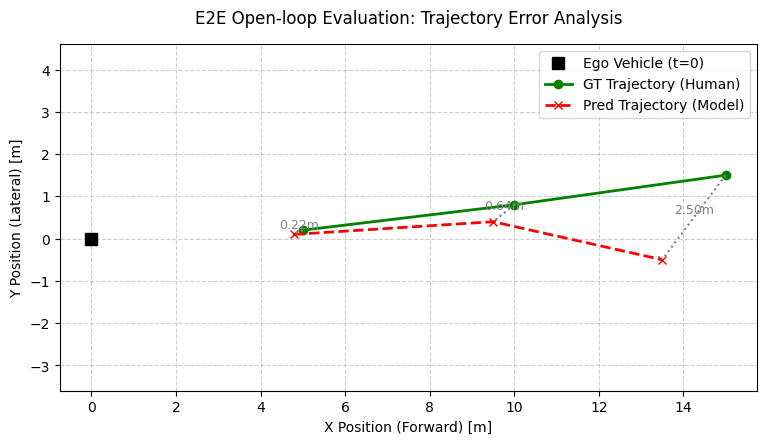

In [ ]:
# ==========================================
# E2E 玩具代码：开环轨迹误差 (ADE/FDE) 与 控制误差
# ==========================================

# 1. 模拟数据准备 (Mock Data)
# 假设我们评测未来 3 秒的轨迹，每秒 1 个点 (x, y) 坐标，单位: 米
# GT: 人类老司机的真实行驶轨迹 (稍微往左变道)
gt_trajectory = np.array([
    [5.0, 0.2],   # t=1s
    [10.0, 0.8],  # t=2s
    [15.0, 1.5]   # t=3s
])

# Pred: E2E 模型输出的预测轨迹 (前期准，后期偏离)
pred_trajectory = np.array([
    [4.8, 0.1],   # t=1s
    [9.5, 0.4],   # t=2s
    [13.5, -0.5]  # t=3s (终点发生明显偏离)
])

# 模拟底盘控制指令输出 (方向盘转角，单位：度)
gt_steering = np.array([2.0, 3.5, 1.0])
pred_steering = np.array([1.8, 4.0, -1.0])

# ==========================================
# 2. 计算轨迹指标：ADE & FDE
# ==========================================
# 计算每个时间点预测轨迹与真实轨迹的欧式距离 (L2 Norm)
point_errors = np.linalg.norm(gt_trajectory - pred_trajectory, axis=1)

# ADE (平均位移误差)
ade = np.mean(point_errors)
# FDE (最终位移误差: 只看最后一个点的距离)
fde = point_errors[-1]

print("--- 1️⃣ 轨迹误差评测 (Trajectory Errors) ---")
print(f"每秒位置误差 (m): {np.round(point_errors, 2)}")
print(f"🎯 ADE (平均位移误差): {ade:.2f} m")
print(f"🎯 FDE (最终位移误差): {fde:.2f} m")

# Miss Rate (漏报率)：设定阈值判定是否偏离过大
MISS_THRESHOLD = 2.0
is_miss = fde > MISS_THRESHOLD
print(f"⚠️ 轨迹严重偏离 (Miss): {'Yes' if is_miss else 'No'} (阈值 > {MISS_THRESHOLD}m)\n")

# ==========================================
# 3. 计算控制指标：Steering Error
# ==========================================
# 计算方向盘转角的平均绝对误差 (MAE)
mean_steering_error = np.mean(np.abs(gt_steering - pred_steering))

print("--- 2️⃣ 控制误差评测 (Control Errors) ---")
print(f"方向盘角度瞬时误差 (度): {np.round(np.abs(gt_steering - pred_steering), 2)}")
print(f"🕹️ 平均方向盘误差 (MAE): {mean_steering_error:.2f} 度\n")

# ==========================================
# 4. 可视化直观对比
# ==========================================
plt.figure(figsize=(9, 4.5))
# 画出自车起点 (原点)
plt.plot(0, 0, 'ks', markersize=8, label='Ego Vehicle (t=0)') 

# 画出 GT 轨迹和预测轨迹
plt.plot(gt_trajectory[:, 0], gt_trajectory[:, 1], 'g-o', linewidth=2, label='GT Trajectory (Human)')
plt.plot(pred_trajectory[:, 0], pred_trajectory[:, 1], 'r--x', linewidth=2, label='Pred Trajectory (Model)')

# 用灰色虚线连接对应时间点的误差，直观展示物理距离
for i in range(len(gt_trajectory)):
    plt.plot([gt_trajectory[i, 0], pred_trajectory[i, 0]], 
             [gt_trajectory[i, 1], pred_trajectory[i, 1]], 'gray', linestyle=':')
    # 在线上标注误差数值
    mid_x = (gt_trajectory[i, 0] + pred_trajectory[i, 0]) / 2
    mid_y = (gt_trajectory[i, 1] + pred_trajectory[i, 1]) / 2
    plt.text(mid_x, mid_y + 0.1, f'{point_errors[i]:.2f}m', color='gray', fontsize=9, ha='center')

plt.title("E2E Open-loop Evaluation: Trajectory Error Analysis", pad=15)
plt.xlabel("X Position (Forward) [m]")
plt.ylabel("Y Position (Lateral) [m]")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal') # 保证 X 轴和 Y 轴的物理比例1:1，视觉才不会失真
plt.show()

--- 🚦 驾驶行为指标评测 (Driving Behavior) ---
💥 [安全性 Fail] 发生碰撞！轨迹离障碍物太近了！
⚠️ [合规性 Fail] 发生压线/冲出车道！(在第 [3] 秒处)
🤮 [舒适性 Fail] 冲击度过大 (Max Jerk: 6.5 m/s³)，乘客要晕车了！(可能发生了急刹)
🎯 [任务完成 Pass] 成功抵达终点 (误差 1.0m)。



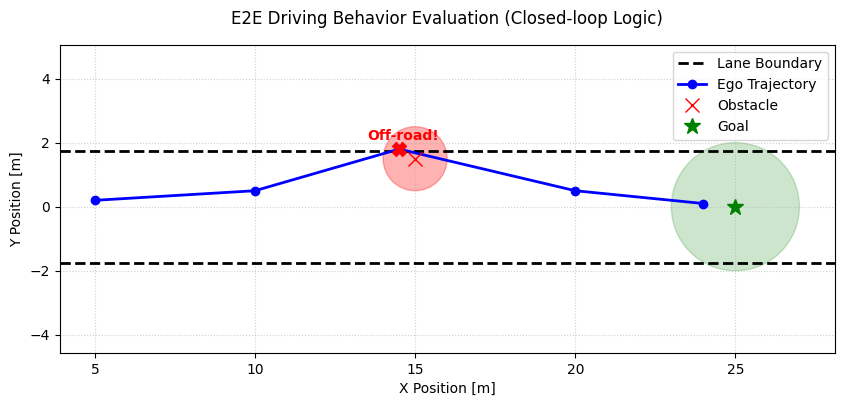

In [ ]:
# ==========================================
# E2E 玩具代码：驾驶行为与物理规则评测 (Driving Behavior Metrics)
# ==========================================

# 1. 模拟闭环环境与模型输出 (Mock Data)
# 模型预测的未来 5 秒轨迹 (每秒 1 个点)
pred_trajectory = np.array([
    [5.0, 0.2],   # t=1s: 正常直行
    [10.0, 0.5],  # t=2s: 开始偏移
    [14.5, 1.8],  # t=3s: 突然向左猛打方向盘避障，但偏得太多了
    [20.0, 0.5],  # t=4s: 回到正轨
    [24.0, 0.1]   # t=5s: 到达终点附近
])

# 假设模型输出的连续加速度 (m/s^2)
accelerations = np.array([1.0, 1.5, -5.0, 0.5, 1.0]) 

# 设定道路物理环境
lane_width = 3.5  # 标准车道宽度 3.5m (Y轴有效范围: -1.75 到 1.75)
obstacle_pos = np.array([15.0, 1.5])  # 前方有个抛锚的故障车
car_radius = 1.0  # 假设自车碰撞判定半径为 1m
goal_pos = np.array([25.0, 0.0])  # 导航终点
goal_radius = 2.0 # 距离终点 2 米内算作到达

print("--- 🚦 驾驶行为指标评测 (Driving Behavior) ---")

# ==========================================
# 指标 1：安全性 - 碰撞检测 (Collision Rate)
# 逻辑：计算轨迹上每个点到障碍物的距离，小于自车半径即视为碰撞
# ==========================================
distances_to_obs = np.linalg.norm(pred_trajectory - obstacle_pos, axis=1)
min_distance = np.min(distances_to_obs)
is_collision = min_distance < car_radius

if is_collision:
    print("💥 [安全性 Fail] 发生碰撞！轨迹离障碍物太近了！")
else:
    print("✅ [安全性 Pass] 未发生碰撞。")

# ==========================================
# 指标 2：合规性 - 车道违规 (Lane Violation / Off-road)
# 逻辑：判断轨迹的 Y 坐标绝对值是否超过了车道边界的一半
# ==========================================
lane_boundary = lane_width / 2.0
out_of_lane_points = np.where(np.abs(pred_trajectory[:, 1]) > lane_boundary)[0]
is_out_of_lane = len(out_of_lane_points) > 0

if is_out_of_lane:
    print(f"⚠️ [合规性 Fail] 发生压线/冲出车道！(在第 {out_of_lane_points + 1} 秒处)")
else:
    print("✅ [合规性 Pass] 始终保持在车道内。")

# ==========================================
# 指标 3：舒适性 - 冲击度 (Jerk)
# 逻辑：Jerk 是加速度的导数(变化率)。急刹车会导致剧烈的负 Jerk。
# ==========================================
dt = 1.0 # 时间间隔 1s
jerks = np.diff(accelerations) / dt
max_abs_jerk = np.max(np.abs(jerks))
JERK_THRESHOLD = 3.0 # 超过 3.0 m/s^3 乘客会极度不适

if max_abs_jerk > JERK_THRESHOLD:
    print(f"🤮 [舒适性 Fail] 冲击度过大 (Max Jerk: {max_abs_jerk:.1f} m/s³)，乘客要晕车了！(可能发生了急刹)")
else:
    print(f"✅ [舒适性 Pass] 加减速平稳 (Max Jerk: {max_abs_jerk:.1f} m/s³)。")

# ==========================================
# 指标 4：任务完成度 (Route Completion)
# 逻辑：判断轨迹最后一个点是否成功抵达导航终点附近
# ==========================================
dist_to_goal = np.linalg.norm(pred_trajectory[-1] - goal_pos)
is_completed = dist_to_goal <= goal_radius

if is_completed:
    print(f"🎯 [任务完成 Pass] 成功抵达终点 (误差 {dist_to_goal:.1f}m)。\n")
else:
    print(f"❌ [任务完成 Fail] 未能到达终点 (距离终点还有 {dist_to_goal:.1f}m)。\n")


# ==========================================
# 5. 驾驶行为可视化 (直观分析为何 Fail)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 4))

# 绘制车道边界
ax.axhline(lane_boundary, color='black', linestyle='--', linewidth=2, label='Lane Boundary')
ax.axhline(-lane_boundary, color='black', linestyle='--', linewidth=2)

# 绘制预测轨迹
ax.plot(pred_trajectory[:, 0], pred_trajectory[:, 1], 'b-o', linewidth=2, label='Ego Trajectory')

# 绘制障碍物及其碰撞判定区域
obs_circle = patches.Circle(obstacle_pos, car_radius, color='red', alpha=0.3)
ax.add_patch(obs_circle)
ax.plot(obstacle_pos[0], obstacle_pos[1], 'rx', markersize=10, label='Obstacle')

# 绘制终点区域
goal_circle = patches.Circle(goal_pos, goal_radius, color='green', alpha=0.2)
ax.add_patch(goal_circle)
ax.plot(goal_pos[0], goal_pos[1], 'g*', markersize=12, label='Goal')

# 标记出界点
for idx in out_of_lane_points:
    ax.plot(pred_trajectory[idx, 0], pred_trajectory[idx, 1], 'rX', markersize=10)
    ax.text(pred_trajectory[idx, 0]-1, pred_trajectory[idx, 1]+0.3, 'Off-road!', color='red', weight='bold')

plt.title("E2E Driving Behavior Evaluation (Closed-loop Logic)", pad=15)
plt.xlabel("X Position [m]")
plt.ylabel("Y Position [m]")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal')
plt.show()